In [ ]:
!pip install neuprint-python

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from itertools import combinations
from scipy.stats import spearmanr, pearsonr
from neuprint import Client, fetch_synapse_connections, fetch_adjacencies, NeuronCriteria as NC
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

In [ ]:

# Read authentication token
from google.colab import userdata
auth_token = userdata.get('NEUPRINT_TOKEN')

# Connect to Neuprint
np_client = Client('neuprint.janelia.org', dataset='hemibrain:v1.2.1', token=auth_token)
print(f"Connected to neuprint.janelia.org (hemibrain:v1.2.1)")

In [2]:
print("Querying Hemibrain for True Hubs (by UNIQUE presynaptic partners)...")

# This Cypher query explicitly counts DISTINCT presynaptic body IDs.
cypher_query = """
MATCH (pre:Neuron)-[:ConnectsTo]->(post:Neuron {status: 'Traced', cropped: false})
RETURN post.bodyId AS bodyId, post.type AS type, count(DISTINCT pre.bodyId) AS unique_in_degree
ORDER BY unique_in_degree DESC
LIMIT 50
"""
hubs_df = np_client.fetch_custom(cypher_query)

print("\nTop 10 True Hubs:")
display(hubs_df.head(10))

# Let's take the #1 Hub to start our pipeline
TARGET_HUB = hubs_df.iloc[0]['bodyId']
TARGET_TYPE = hubs_df.iloc[0]['type']
print(f"\n---> Selected Target Hub: {TARGET_HUB} ({TARGET_TYPE})")

Querying Hemibrain for True Hubs (by UNIQUE presynaptic partners)...

Top 10 True Hubs:


,bodyId,type,unique_in_degree
0,2124762952,mALC2,4388
1,425790257,APL,3146
2,329566174,OA-VPM3,3119
3,1640909284,lLN2F_b,3020
4,425276848,DPM,2997
5,5901218894,lLN2F_a,2774
6,5813024698,lLN2F_b,2748
7,1670287030,lLN2F_a,2699
8,1628523730,mALC1,2679
9,1343403608,None,2654



---> Selected Target Hub: 2124762952 (mALC2)


Fetching synapses for Hub 2124762952...


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/19584 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Calculating physical centroids for each presynaptic neuron...
Found 4388 unique presynaptic neurons.
Fetching connections between these presynaptic neurons...


  0%|          | 0/22 [00:00<?, ?it/s]

0it [00:00, ?it/s]

Calculating physical distances between all neuron pairs...
Merging data and plotting...
Total possible pairs: 9,625,078
Actually connected pairs: 99,285


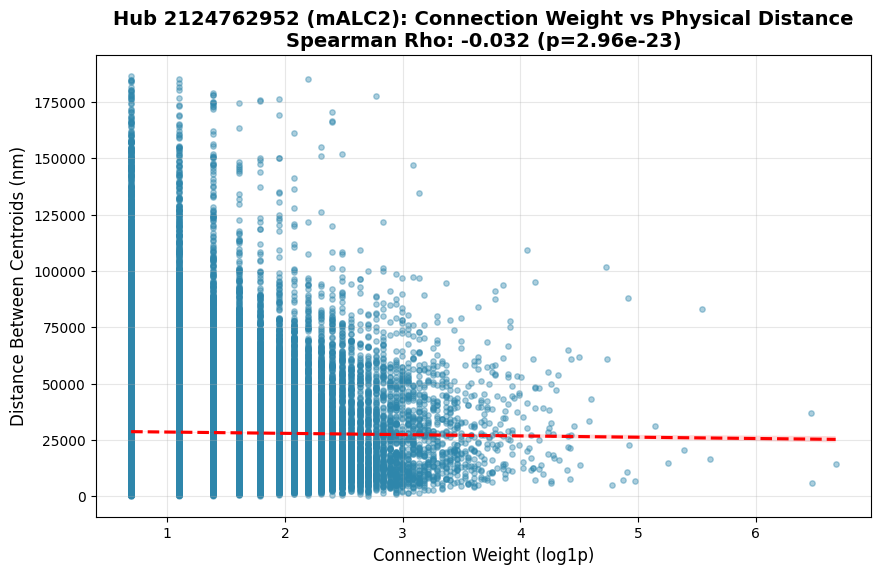

In [3]:
# ==========================================
# PHASE 2: Get Synapses & Centroids
# ==========================================
print(f"Fetching synapses for Hub {TARGET_HUB}...")
synapses_df = fetch_synapse_connections(None, TARGET_HUB)

# Keep only synapses going INTO the hub
synapses_df = synapses_df[synapses_df['bodyId_post'] == TARGET_HUB].copy()

# Calculate the 3D Centroid for EVERY individual presynaptic neuron
print("Calculating physical centroids for each presynaptic neuron...")
centroids_df = synapses_df.groupby('bodyId_pre')[['x_pre', 'y_pre', 'z_pre']].mean()
pre_neurons = centroids_df.index.tolist()

print(f"Found {len(pre_neurons)} unique presynaptic neurons.")

# ==========================================
# PHASE 3: Fetch Subconnectome (Weights)
# ==========================================
print("Fetching connections between these presynaptic neurons...")
_, edges_df = fetch_adjacencies(NC(bodyId=pre_neurons), NC(bodyId=pre_neurons))

# We want UNDIRECTED weights (A->B + B->A) so we don't treat A-B and B-A as different pairs
edges_df['neuron_1'] = np.minimum(edges_df['bodyId_pre'], edges_df['bodyId_post'])
edges_df['neuron_2'] = np.maximum(edges_df['bodyId_pre'], edges_df['bodyId_post'])

# Sum weights for each unique pair
weights_df = edges_df.groupby(['neuron_1', 'neuron_2'], as_index=False)['weight'].sum()

# ==========================================
# PHASE 4: Calculate Pairwise Distances
# ==========================================
print("Calculating physical distances between all neuron pairs...")
# Calculate distances between all centroids
distances = pdist(centroids_df.values, metric='euclidean')

# Create a DataFrame of all possible pairs and their distances
pairs = list(combinations(centroids_df.index, 2))
distances_df = pd.DataFrame(pairs, columns=['neuron_1', 'neuron_2'])

# Ensure neuron_1 is always the smaller ID so it matches our weights_df
distances_df['n1_temp'] = np.minimum(distances_df['neuron_1'], distances_df['neuron_2'])
distances_df['n2_temp'] = np.maximum(distances_df['neuron_1'], distances_df['neuron_2'])
distances_df['neuron_1'] = distances_df['n1_temp']
distances_df['neuron_2'] = distances_df['n2_temp']
distances_df = distances_df.drop(columns=['n1_temp', 'n2_temp'])

distances_df['distance_nm'] = distances * 8 # Hemibrain voxels are 8x8x8 nm

# ==========================================
# PHASE 5: Merge & Plot
# ==========================================
print("Merging data and plotting...")
# Merge weights into the distance dataframe
# Pairs that don't exist in weights_df will get NaN, which we fill with 0
final_df = distances_df.merge(weights_df, on=['neuron_1', 'neuron_2'], how='left')
final_df['weight'] = final_df['weight'].fillna(0)

# FILTER: We only want to plot pairs that ACTUALLY connect to each other (weight > 0)
connected_pairs = final_df[final_df['weight'] > 0].copy()
connected_pairs['log_weight'] = np.log1p(connected_pairs['weight'])

print(f"Total possible pairs: {len(final_df):,}")
print(f"Actually connected pairs: {len(connected_pairs):,}")

# --- PLOTTING ---
plt.figure(figsize=(10, 6))
sns.regplot(
    data=connected_pairs,
    x='log_weight',
    y='distance_nm',
    scatter_kws={'alpha':0.4, 's':15, 'color':'#2E86AB'},
    line_kws={'color':'red', 'linestyle':'--'}
)

# Statistics
rho, p_val = spearmanr(connected_pairs['log_weight'], connected_pairs['distance_nm'])

plt.title(f"Hub {TARGET_HUB} ({TARGET_TYPE}): Connection Weight vs Physical Distance\nSpearman Rho: {rho:.3f} (p={p_val:.2e})", fontsize=14, fontweight='bold')
plt.xlabel("Connection Weight (log1p)", fontsize=12)
plt.ylabel("Distance Between Centroids (nm)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

Processing 50 hubs using 2 parallel workers...


Processing Hubs:   0%|          | 0/50 [00:00<?, ?it/s]


Pooling data...
Total connected pairs pooled across 50 hubs: 7,649,503

--- POOLED STATISTICS ---
Spearman Rho: -0.0175 (p = 0.00e+00)
Pearson R:    0.0092 (p = 2.72e-142)


KeyboardInterrupt: 

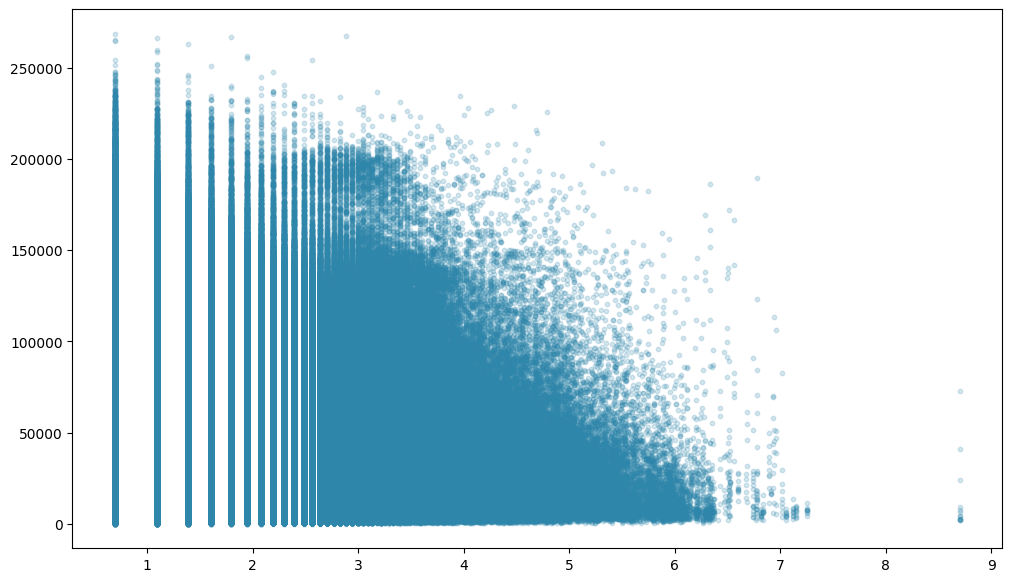

In [9]:
# ==========================================
# Process Each Hub
# ==========================================
from multiprocessing import Pool, cpu_count

def process_single_hub(hub_id):
    """Worker function to process a single hub."""
    try:
        # 1. Fetch Synapses into this hub
        synapses_df = fetch_synapse_connections(None, hub_id)
        synapses_df = synapses_df[synapses_df['bodyId_post'] == hub_id].copy()

        if len(synapses_df) == 0:
            return None

        # 2. Calculate physical centroid for each unique presynaptic neuron
        centroids_df = synapses_df.groupby('bodyId_pre')[['x_pre', 'y_pre', 'z_pre']].mean()
        pre_neurons = centroids_df.index.tolist()

        # Only calculate if we have at least 2 presynaptic neurons
        if len(pre_neurons) < 2:
            return None

        # 3. Fetch connections among these presynaptic neurons
        _, edges_df = fetch_adjacencies(NC(bodyId=pre_neurons), NC(bodyId=pre_neurons))

        if len(edges_df) == 0:
            return None

        # Make connections undirected (sum A->B and B->A)
        edges_df['neuron_1'] = np.minimum(edges_df['bodyId_pre'], edges_df['bodyId_post'])
        edges_df['neuron_2'] = np.maximum(edges_df['bodyId_pre'], edges_df['bodyId_post'])
        weights_df = edges_df.groupby(['neuron_1', 'neuron_2'], as_index=False)['weight'].sum()

        # 4. Calculate pairwise Euclidean distances between centroids
        distances = pdist(centroids_df.values, metric='euclidean')
        pairs = list(combinations(centroids_df.index, 2))
        distances_df = pd.DataFrame(pairs, columns=['neuron_1', 'neuron_2'])

        # Ensure n1 is always the smaller ID to match weights_df
        distances_df['n1_temp'] = np.minimum(distances_df['neuron_1'], distances_df['neuron_2'])
        distances_df['n2_temp'] = np.maximum(distances_df['neuron_1'], distances_df['neuron_2'])
        distances_df['neuron_1'] = distances_df['n1_temp']
        distances_df['neuron_2'] = distances_df['n2_temp']
        distances_df.drop(columns=['n1_temp', 'n2_temp'], inplace=True)

        # Convert hemibrain voxels to nanometers
        distances_df['distance_nm'] = distances * 8

        # 5. Merge distances and weights
        hub_merged_df = distances_df.merge(weights_df, on=['neuron_1', 'neuron_2'], how='left')
        hub_merged_df['weight'] = hub_merged_df['weight'].fillna(0)

        # Filter ONLY for pairs that are physically connected
        connected_only = hub_merged_df[hub_merged_df['weight'] > 0].copy()

        # Tag which hub this came from (in case you want to color code later)
        connected_only['hub_bodyId'] = hub_id

        return connected_only

    except Exception as e:
        # Silently catch API disconnects/timeouts so the entire pool doesn't crash
        return None


hub_list = hubs_df['bodyId'].tolist()
n_workers = min(16, cpu_count())

print(f"Processing {len(hub_list)} hubs using {n_workers} parallel workers...")

# Execute the parallel pool
with Pool(n_workers) as pool:
    results = list(tqdm(
        pool.imap(process_single_hub, hub_list),
        total=len(hub_list),
        desc="Processing Hubs"
    ))

# Filter out Nones from failed/empty hub calculations
all_connected_pairs = [res for res in results if res is not None and not res.empty]

print("\nPooling data...")
final_pooled_df = pd.concat(all_connected_pairs, ignore_index=True)

# Log transform the weight
final_pooled_df['log_weight'] = np.log1p(final_pooled_df['weight'])

print(f"Total connected pairs pooled across {len(hub_list)} hubs: {len(final_pooled_df):,}")

# Calculate Statistics
rho, p_val_spearman = spearmanr(final_pooled_df['log_weight'], final_pooled_df['distance_nm'])
r_p, p_val_pearson = pearsonr(final_pooled_df['log_weight'], final_pooled_df['distance_nm'])

print("\n--- POOLED STATISTICS ---")
print(f"Spearman Rho: {rho:.4f} (p = {p_val_spearman:.2e})")
print(f"Pearson R:    {r_p:.4f} (p = {p_val_pearson:.2e})")

# --- Plotting ---
plt.figure(figsize=(12, 7))

# We use a slight transparency (alpha) because millions of points will overlap
sns.regplot(
    data=final_pooled_df,
    x='log_weight',
    y='distance_nm',
    scatter_kws={'alpha':0.2, 's':10, 'color':'#2E86AB'},
    line_kws={'color':'red', 'linestyle':'--', 'linewidth': 3}
)

plt.title(f"Brain-Wide Hub Inputs: Connection Weight vs Physical Distance\n(Pooled across Top {len(hub_list)} Hubs | n={len(final_pooled_df):,} pairs)\nSpearman Rho: {rho:.3f} | Pearson R: {r_p:.3f}", fontsize=14, fontweight='bold')
plt.xlabel("Connection Weight (log1p)", fontsize=12)
plt.ylabel("Distance Between Centroids (nm)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

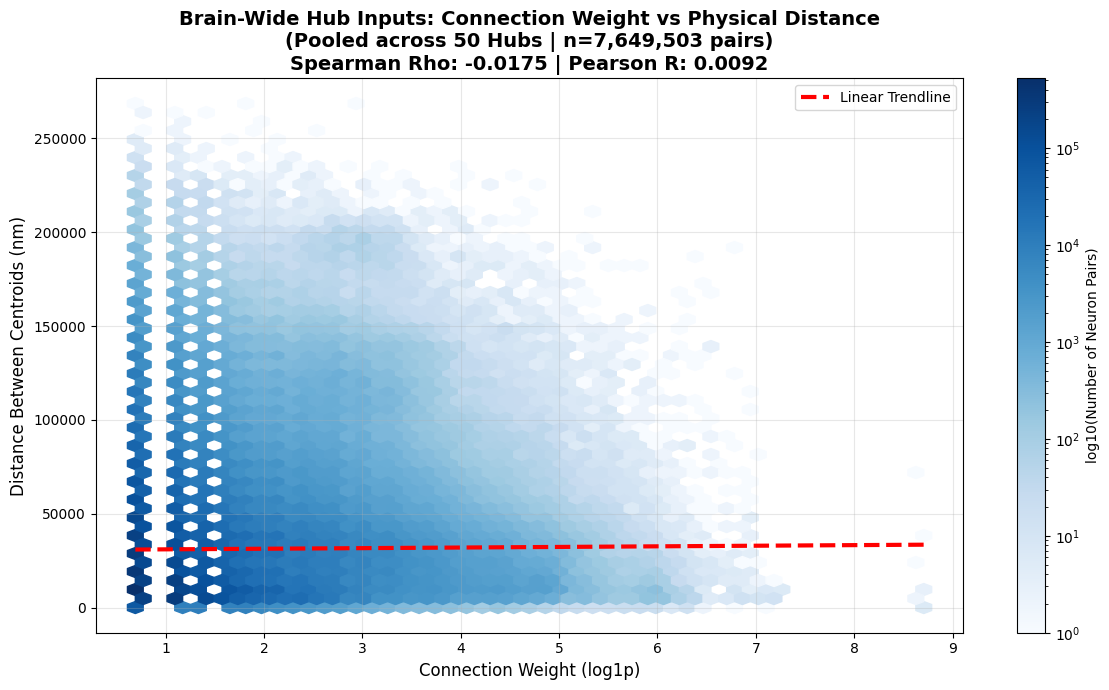

In [10]:
plt.figure(figsize=(12, 7))

# 1. Use a Hexbin plot to handle 7.6 million points instantly
# (Darker hexagons = more overlapping pairs in that region)
hb = plt.hexbin(
    final_pooled_df['log_weight'],
    final_pooled_df['distance_nm'],
    gridsize=50,
    cmap='Blues',
    mincnt=1,
    bins='log' # Log color scale so we can see the less dense areas
)
cb = plt.colorbar(hb)
cb.set_label('log10(Number of Neuron Pairs)')

# 2. Calculate and draw the trendline manually (instantly)
m, b = np.polyfit(final_pooled_df['log_weight'], final_pooled_df['distance_nm'], 1)
x_line = np.linspace(final_pooled_df['log_weight'].min(), final_pooled_df['log_weight'].max(), 100)
plt.plot(x_line, m*x_line + b, color='red', linestyle='--', linewidth=3, label="Linear Trendline")

plt.title(f"Brain-Wide Hub Inputs: Connection Weight vs Physical Distance\n(Pooled across 50 Hubs | n={len(final_pooled_df):,} pairs)\nSpearman Rho: {rho:.4f} | Pearson R: {r_p:.4f}", fontsize=14, fontweight='bold')
plt.xlabel("Connection Weight (log1p)", fontsize=12)
plt.ylabel("Distance Between Centroids (nm)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Based on the analysis of over 7.6 million neuron pairs, we can conclude that the physical distance between neuron centers does not directly predict how strongly they connect. The statistical correlation is practically zero (Spearman Rho = -0.0175), and the trendline is completely flat.

Biologically, this makes perfect sense. We are measuring the distance between the "centers" of the neurons, but neurons aren't just single dots in space. They have long, branching axons and dendrites. Two neurons could have their main centers located on opposite sides of the brain, but still send long branches into the exact same microscopic area to form dozens of synapses.

However, looking at the shape of the graph reveals a more nuanced rule. While weak connections happen at any distance, the scatter plot shows a clear drop-off on the right side: the absolute strongest connections only ever happen when the neurons are relatively close together.

IN CONCLUSION: Being close together doesn't guarantee that two neurons will have a strong connection, but being close seems to be a physical requirement for the strongest connections to form.